# Air Quality Monitoring and Pollution Pattern Analysis Using Big Data

### Big Data Essentials Project

**Technologies Used:**  
Python, PySpark, Apache Spark, Spark MLlib, Pandas, Matplotlib

**Dataset:** Air Quality Data in India (2015–2020)

### Project Objective

This project analyzes large-scale air-quality data collected from monitoring
stations across India. PySpark is used for distributed data processing,
preprocessing, classification, clustering, exploratory analysis, and
pollution pattern identification.

The project consists of two major machine learning tasks:

1. **Classification** – Predict AQI categories using pollutant measurements.
2. **Clustering** – Group monitoring stations according to their pollution profiles.

The project also performs temporal, city-wise, and pollutant-level analysis
to identify important air-pollution patterns.

In [1]:
!pip install -q pyspark

In [2]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("AirQualityBigData") \
    .getOrCreate()

print("Spark version:", spark.version)
print("Spark started successfully!")

Spark version: 4.0.4
Spark started successfully!


In [3]:
from google.colab import files

uploaded = files.upload()

Saving station_hour.csv to station_hour.csv
Saving stations.csv to stations.csv


In [4]:
# Load the hourly air-quality dataset into Spark

df = spark.read.csv(
    "station_hour.csv",
    header=True,
    inferSchema=True
)

print("Dataset loaded successfully!")
print("Number of rows:", df.count())
print("Number of columns:", len(df.columns))

Dataset loaded successfully!
Number of rows: 2589083
Number of columns: 16


In [5]:
# Display the column names and data types

df.printSchema()

print("Columns:")
print(df.columns)

root
 |-- StationId: string (nullable = true)
 |-- Datetime: timestamp (nullable = true)
 |-- PM2.5: double (nullable = true)
 |-- PM10: double (nullable = true)
 |-- NO: double (nullable = true)
 |-- NO2: double (nullable = true)
 |-- NOx: double (nullable = true)
 |-- NH3: double (nullable = true)
 |-- CO: double (nullable = true)
 |-- SO2: double (nullable = true)
 |-- O3: double (nullable = true)
 |-- Benzene: double (nullable = true)
 |-- Toluene: double (nullable = true)
 |-- Xylene: double (nullable = true)
 |-- AQI: double (nullable = true)
 |-- AQI_Bucket: string (nullable = true)

Columns:
['StationId', 'Datetime', 'PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene', 'AQI', 'AQI_Bucket']


In [7]:
from pyspark.sql import functions as F

missing_values = df.select([
    F.sum(F.col(f"`{c}`").isNull().cast("int")).alias(c)
    for c in df.columns
])

missing_values.show(truncate=False)

+---------+--------+------+-------+------+------+------+-------+------+------+------+-------+-------+-------+------+----------+
|StationId|Datetime|PM2.5 |PM10   |NO    |NO2   |NOx   |NH3    |CO    |SO2   |O3    |Benzene|Toluene|Xylene |AQI   |AQI_Bucket|
+---------+--------+------+-------+------+------+------+-------+------+------+------+-------+-------+-------+------+----------+
|0        |0       |647689|1119252|553711|528973|490808|1236618|499302|742737|725973|861579 |1042366|2075104|570190|570190    |
+---------+--------+------+-------+------+------+------+-------+------+------+------+-------+-------+-------+------+----------+



In [8]:
# Calculate missing-value percentage for every column

total_rows = df.count()

missing_summary = df.select([
    F.round(
        F.sum(F.col(f"`{c}`").isNull().cast("int")) / total_rows * 100,
        2
    ).alias(c)
    for c in df.columns
])

missing_summary.show(truncate=False)

+---------+--------+-----+-----+-----+-----+-----+-----+-----+-----+-----+-------+-------+------+-----+----------+
|StationId|Datetime|PM2.5|PM10 |NO   |NO2  |NOx  |NH3  |CO   |SO2  |O3   |Benzene|Toluene|Xylene|AQI  |AQI_Bucket|
+---------+--------+-----+-----+-----+-----+-----+-----+-----+-----+-----+-------+-------+------+-----+----------+
|0.0      |0.0     |25.02|43.23|21.39|20.43|18.96|47.76|19.28|28.69|28.04|33.28  |40.26  |80.15 |22.02|22.02     |
+---------+--------+-----+-----+-----+-----+-----+-----+-----+-----+-----+-------+-------+------+-----+----------+



In [9]:
# Check the distribution of AQI categories

df.groupBy("AQI_Bucket") \
  .count() \
  .orderBy(F.desc("count")) \
  .show()

+------------+------+
|  AQI_Bucket| count|
+------------+------+
|    Moderate|675008|
|        NULL|570190|
|Satisfactory|530164|
|   Very Poor|301150|
|        Poor|239990|
|        Good|152113|
|      Severe|120468|
+------------+------+



In [10]:
# Rename columns for easier Spark processing

df_clean = df.withColumnRenamed("PM2.5", "PM25") \
            .withColumnRenamed("PM10", "PM10") \
            .withColumnRenamed("NO2", "NO2") \
            .withColumnRenamed("SO2", "SO2") \
            .withColumnRenamed("AQI_Bucket", "AQI_Bucket")

print("Working dataset created.")
df_clean.printSchema()

Working dataset created.
root
 |-- StationId: string (nullable = true)
 |-- Datetime: timestamp (nullable = true)
 |-- PM25: double (nullable = true)
 |-- PM10: double (nullable = true)
 |-- NO: double (nullable = true)
 |-- NO2: double (nullable = true)
 |-- NOx: double (nullable = true)
 |-- NH3: double (nullable = true)
 |-- CO: double (nullable = true)
 |-- SO2: double (nullable = true)
 |-- O3: double (nullable = true)
 |-- Benzene: double (nullable = true)
 |-- Toluene: double (nullable = true)
 |-- Xylene: double (nullable = true)
 |-- AQI: double (nullable = true)
 |-- AQI_Bucket: string (nullable = true)



# 4. Problem Statement

Air pollution is a major environmental and public-health concern in India.
Air-quality monitoring stations continuously collect measurements of
pollutants such as PM2.5, PM10, NO2, SO2, CO, and O3.

The large volume of monitoring data makes it necessary to use scalable
Big Data technologies for efficient processing and analysis.

### Objectives

- Analyze large-scale air-quality data using PySpark.
- Preprocess and clean pollutant measurements.
- Predict AQI categories using classification algorithms.
- Group monitoring stations based on their pollution characteristics.
- Identify temporal and city-wise pollution patterns.
- Use Spark and Parquet for efficient Big Data processing.

# PART I — CLASSIFICATION

## 5. Data Preprocessing

In [11]:
# Prepare data for classification

classification_df = df_clean.select(
    "PM25",
    "PM10",
    "NO2",
    "SO2",
    "CO",
    "O3",
    "AQI_Bucket"
).dropna()

print("Classification dataset created.")
print("Rows:", classification_df.count())
classification_df.show(5)

Classification dataset created.
Rows: 1034276
+-----+------+-----+-----+---+------+----------+
| PM25|  PM10|  NO2|  SO2| CO|    O3|AQI_Bucket|
+-----+------+-----+-----+---+------+----------+
|104.0| 148.5| 23.0| 15.3|0.1|117.62|  Moderate|
| 94.5| 142.0|16.25| 17.0|0.1|136.23|  Moderate|
|82.75| 126.5|14.83| 15.4|0.1|149.92|  Moderate|
| 68.5| 117.0| 13.6| 21.8|0.1| 161.7|  Moderate|
|69.25|112.25| 11.8|21.38|0.1|161.68|  Moderate|
+-----+------+-----+-----+---+------+----------+
only showing top 5 rows


### 5.1 Selecting Classification Features

The following pollutant features are used to predict the AQI category:
PM2.5, PM10, NO2, SO2, CO, and O3.

AQI itself is excluded because it is directly related to the AQI category target.
Records containing missing values in the selected features are removed.

In [12]:
# Check class distribution after cleaning

classification_df.groupBy("AQI_Bucket") \
    .count() \
    .orderBy(F.desc("count")) \
    .show()

+------------+------+
|  AQI_Bucket| count|
+------------+------+
|    Moderate|374567|
|Satisfactory|257330|
|   Very Poor|140614|
|        Poor|123244|
|        Good| 78877|
|      Severe| 59644|
+------------+------+



### 5.2 Encoding the Target Variable

The AQI category (`AQI_Bucket`) is a categorical variable.
StringIndexer converts each category into a numerical label so that it can
be used by Spark MLlib classification algorithms.

In [13]:
from pyspark.ml.feature import StringIndexer

# Convert AQI categories into numeric labels
label_indexer = StringIndexer(
    inputCol="AQI_Bucket",
    outputCol="label"
)

classification_labeled = label_indexer.fit(
    classification_df
).transform(classification_df)

classification_labeled.select(
    "AQI_Bucket", "label"
).distinct().orderBy("label").show()

+------------+-----+
|  AQI_Bucket|label|
+------------+-----+
|    Moderate|  0.0|
|Satisfactory|  1.0|
|   Very Poor|  2.0|
|        Poor|  3.0|
|        Good|  4.0|
|      Severe|  5.0|
+------------+-----+



### 5.3 Feature Vector Assembly

The selected pollutant features are combined into a single feature vector using
Spark MLlib's VectorAssembler. This vector is used as the input to the
classification models.

In [14]:
from pyspark.ml.feature import VectorAssembler

feature_columns = [
    "PM25",
    "PM10",
    "NO2",
    "SO2",
    "CO",
    "O3"
]

assembler = VectorAssembler(
    inputCols=feature_columns,
    outputCol="features"
)

classification_ready = assembler.transform(classification_labeled)

classification_ready.select(
    "features",
    "label"
).show(5, truncate=False)

+------------------------------------+-----+
|features                            |label|
+------------------------------------+-----+
|[104.0,148.5,23.0,15.3,0.1,117.62]  |0.0  |
|[94.5,142.0,16.25,17.0,0.1,136.23]  |0.0  |
|[82.75,126.5,14.83,15.4,0.1,149.92] |0.0  |
|[68.5,117.0,13.6,21.8,0.1,161.7]    |0.0  |
|[69.25,112.25,11.8,21.38,0.1,161.68]|0.0  |
+------------------------------------+-----+
only showing top 5 rows


### 5.4 Train-Test Split

The prepared dataset is divided into training and testing subsets using an
80:20 split with a fixed random seed of 42. The training data is used to build
the classification models, while the test data is used for evaluation.

In [15]:
# Split data into training and testing sets

train_df, test_df = classification_ready.randomSplit(
    [0.8, 0.2],
    seed=42
)

print("Training records:", train_df.count())
print("Testing records:", test_df.count())

Training records: 827405
Testing records: 206871


## 6. Model Selection and Justification

Two classification algorithms are evaluated in this project:

1. **Random Forest Classifier**
2. **Logistic Regression**

Random Forest is selected as the primary model because it can capture
non-linear relationships between pollutant concentrations and AQI categories,
while also providing feature importance values.

Logistic Regression is used as a baseline model for comparison.

In [16]:
from pyspark.ml.classification import RandomForestClassifier

# Create Random Forest classifier
rf = RandomForestClassifier(
    featuresCol="features",
    labelCol="label",
    numTrees=50,
    maxDepth=10,
    seed=42
)

# Train the model
rf_model = rf.fit(train_df)

print("Random Forest training completed!")

Random Forest training completed!


### 7.1 Random Forest Predictions

The trained Random Forest model is applied to the test dataset to generate
predicted AQI categories.

In [17]:
# Make predictions on the test dataset

predictions = rf_model.transform(test_df)

predictions.select(
    "AQI_Bucket",
    "label",
    "prediction"
).show(10)

+------------+-----+----------+
|  AQI_Bucket|label|prediction|
+------------+-----+----------+
|    Moderate|  0.0|       1.0|
|Satisfactory|  1.0|       1.0|
|Satisfactory|  1.0|       4.0|
|    Moderate|  0.0|       1.0|
|Satisfactory|  1.0|       1.0|
|Satisfactory|  1.0|       1.0|
|Satisfactory|  1.0|       1.0|
|Satisfactory|  1.0|       1.0|
|        Good|  4.0|       4.0|
|Satisfactory|  1.0|       4.0|
+------------+-----+----------+
only showing top 10 rows


In [18]:
# Make predictions on the test dataset

predictions = rf_model.transform(test_df)

predictions.select(
    "AQI_Bucket",
    "label",
    "prediction"
).show(10)

+------------+-----+----------+
|  AQI_Bucket|label|prediction|
+------------+-----+----------+
|    Moderate|  0.0|       1.0|
|Satisfactory|  1.0|       1.0|
|Satisfactory|  1.0|       4.0|
|    Moderate|  0.0|       1.0|
|Satisfactory|  1.0|       1.0|
|Satisfactory|  1.0|       1.0|
|Satisfactory|  1.0|       1.0|
|Satisfactory|  1.0|       1.0|
|        Good|  4.0|       4.0|
|Satisfactory|  1.0|       4.0|
+------------+-----+----------+
only showing top 10 rows


## 8. Classification Results

The Random Forest model is evaluated on the test dataset using accuracy,
weighted precision, weighted recall, and F1-score.

In [19]:
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

# Calculate accuracy
accuracy_evaluator = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="accuracy"
)

accuracy = accuracy_evaluator.evaluate(predictions)

print(f"Random Forest Accuracy: {accuracy:.4f}")
print(f"Random Forest Accuracy: {accuracy * 100:.2f}%")

Random Forest Accuracy: 0.6278
Random Forest Accuracy: 62.78%


### 8.1 Precision, Recall and F1-Score

Additional evaluation metrics are calculated to measure the overall
classification performance of the Random Forest model.

- **Weighted Precision:** 61.48%
- **Weighted Recall:** 62.78%
- **Weighted F1-Score:** 61.47%

In [21]:
# Calculate precision, recall and F1-score

metrics = {}

for metric in ["weightedPrecision", "weightedRecall", "f1"]:
    evaluator = MulticlassClassificationEvaluator(
        labelCol="label",
        predictionCol="prediction",
        metricName=metric
    )
    metrics[metric] = evaluator.evaluate(predictions)

print(f"Weighted Precision: {metrics['weightedPrecision']:.4f}")
print(f"Weighted Recall:    {metrics['weightedRecall']:.4f}")
print(f"F1 Score:           {metrics['f1']:.4f}")

Weighted Precision: 0.6148
Weighted Recall:    0.6278
F1 Score:           0.6147


In [ ]:
print(f"Weighted Precision: {metrics['weightedPrecision']:.4f}")
print(f"Weighted Recall:    {metrics['weightedRecall']:.4f}")
print(f"F1 Score:           {metrics['f1']:.4f}")

## 9. Confusion Matrix

The confusion matrix compares the actual AQI categories with the categories
predicted by the Random Forest model. It helps identify which AQI categories
are correctly classified and which categories are frequently confused.

In [22]:
# Create confusion matrix

confusion_matrix = predictions.groupBy(
    "label", "prediction"
).count().orderBy(
    "label", "prediction"
)

confusion_matrix.show()

+-----+----------+-----+
|label|prediction|count|
+-----+----------+-----+
|  0.0|       0.0|56089|
|  0.0|       1.0|12329|
|  0.0|       2.0| 2517|
|  0.0|       3.0| 3210|
|  0.0|       4.0|  501|
|  0.0|       5.0|  153|
|  1.0|       0.0|11270|
|  1.0|       1.0|36234|
|  1.0|       2.0|   60|
|  1.0|       3.0|   44|
|  1.0|       4.0| 4028|
|  1.0|       5.0|    5|
|  2.0|       0.0| 5649|
|  2.0|       1.0|  307|
|  2.0|       2.0|16820|
|  2.0|       3.0| 2928|
|  2.0|       4.0|   10|
|  2.0|       5.0| 2516|
|  3.0|       0.0|12666|
|  3.0|       1.0|  923|
+-----+----------+-----+
only showing top 20 rows


In [23]:
# Show the complete confusion matrix

confusion_matrix.orderBy(
    "label", "prediction"
).show(100, truncate=False)

+-----+----------+-----+
|label|prediction|count|
+-----+----------+-----+
|0.0  |0.0       |56089|
|0.0  |1.0       |12329|
|0.0  |2.0       |2517 |
|0.0  |3.0       |3210 |
|0.0  |4.0       |501  |
|0.0  |5.0       |153  |
|1.0  |0.0       |11270|
|1.0  |1.0       |36234|
|1.0  |2.0       |60   |
|1.0  |3.0       |44   |
|1.0  |4.0       |4028 |
|1.0  |5.0       |5    |
|2.0  |0.0       |5649 |
|2.0  |1.0       |307  |
|2.0  |2.0       |16820|
|2.0  |3.0       |2928 |
|2.0  |4.0       |10   |
|2.0  |5.0       |2516 |
|3.0  |0.0       |12666|
|3.0  |1.0       |923  |
|3.0  |2.0       |5476 |
|3.0  |3.0       |5066 |
|3.0  |4.0       |19   |
|3.0  |5.0       |408  |
|4.0  |0.0       |99   |
|4.0  |1.0       |6213 |
|4.0  |2.0       |1    |
|4.0  |4.0       |9552 |
|5.0  |0.0       |681  |
|5.0  |1.0       |27   |
|5.0  |2.0       |4177 |
|5.0  |3.0       |770  |
|5.0  |4.0       |4    |
|5.0  |5.0       |6119 |
+-----+----------+-----+



### 9.1 Confusion Matrix Visualization

The confusion matrix is visualized as a heatmap to provide a clearer view of
the classification performance across the different AQI categories.

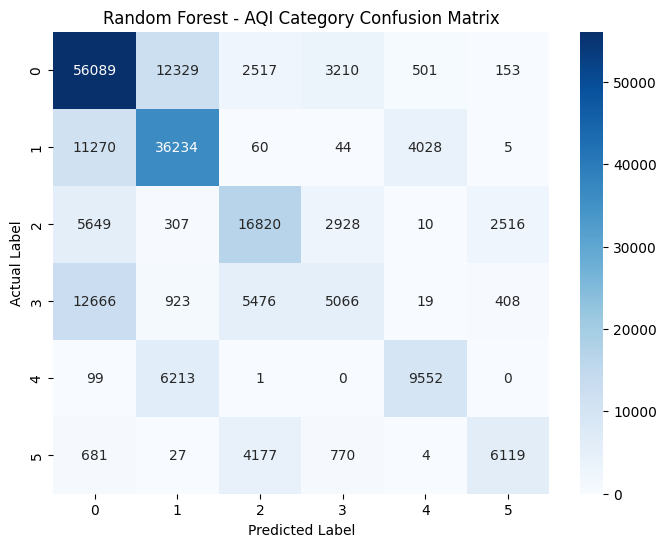

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Convert Spark confusion matrix to Pandas
cm_data = confusion_matrix.collect()

# Create 6x6 matrix
cm = [[0 for _ in range(6)] for _ in range(6)]

for row in cm_data:
    cm[int(row["label"])][int(row["prediction"])] = row["count"]

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=range(6),
    yticklabels=range(6)
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Random Forest - AQI Category Confusion Matrix")
plt.show()

In [25]:
from pyspark.ml.classification import LogisticRegression

# Create Logistic Regression classifier
lr = LogisticRegression(
    featuresCol="features",
    labelCol="label",
    maxIter=50,
    regParam=0.1,
    elasticNetParam=0.0
)

# Train the model
lr_model = lr.fit(train_df)

print("Logistic Regression training completed!")

Logistic Regression training completed!


In [26]:
# Make predictions using Logistic Regression

lr_predictions = lr_model.transform(test_df)

lr_predictions.select(
    "AQI_Bucket",
    "label",
    "prediction"
).show(10)

+------------+-----+----------+
|  AQI_Bucket|label|prediction|
+------------+-----+----------+
|    Moderate|  0.0|       1.0|
|Satisfactory|  1.0|       1.0|
|Satisfactory|  1.0|       1.0|
|    Moderate|  0.0|       1.0|
|Satisfactory|  1.0|       1.0|
|Satisfactory|  1.0|       1.0|
|Satisfactory|  1.0|       0.0|
|Satisfactory|  1.0|       1.0|
|        Good|  4.0|       1.0|
|Satisfactory|  1.0|       1.0|
+------------+-----+----------+
only showing top 10 rows


In [27]:
# Evaluate Logistic Regression

lr_metrics = {}

for metric in ["accuracy", "weightedPrecision", "weightedRecall", "f1"]:
    evaluator = MulticlassClassificationEvaluator(
        labelCol="label",
        predictionCol="prediction",
        metricName=metric
    )
    lr_metrics[metric] = evaluator.evaluate(lr_predictions)

print(f"Accuracy:          {lr_metrics['accuracy']:.4f}")
print(f"Weighted Precision: {lr_metrics['weightedPrecision']:.4f}")
print(f"Weighted Recall:    {lr_metrics['weightedRecall']:.4f}")
print(f"F1 Score:           {lr_metrics['f1']:.4f}")

Accuracy:          0.5108
Weighted Precision: 0.4460
Weighted Recall:    0.5108
F1 Score:           0.4360


## 10. Feature Importance

Random Forest provides feature importance values that indicate the relative
contribution of each pollutant feature to the classification model.

This helps identify which pollutants have the greatest influence on AQI
category prediction.

In [28]:
feature_importance = rf_model.featureImportances

print("Random Forest Feature Importance:")

for feature, importance in zip(feature_columns, feature_importance):
    print(f"{feature}: {importance:.4f}")

Random Forest Feature Importance:
PM25: 0.3362
PM10: 0.4349
NO2: 0.0405
SO2: 0.0098
CO: 0.0747
O3: 0.1038


### 10.1 Feature Importance Visualization

The feature importance values are visualized using a bar chart to compare the
relative contribution of each pollutant to the Random Forest model.

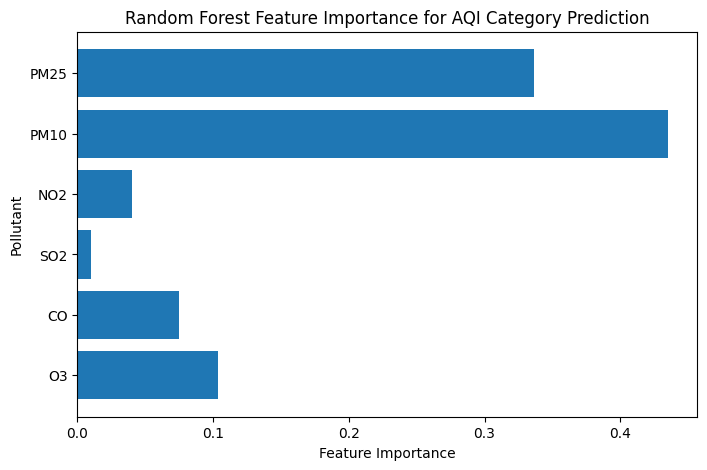

In [29]:
import matplotlib.pyplot as plt

importance_values = rf_model.featureImportances.toArray()

plt.figure(figsize=(8, 5))

plt.barh(feature_columns, importance_values)

plt.xlabel("Feature Importance")
plt.ylabel("Pollutant")
plt.title("Random Forest Feature Importance for AQI Category Prediction")

plt.gca().invert_yaxis()
plt.show()

## 11. Classification Inference

The Random Forest classifier achieved an accuracy of **62.78%**, with a
weighted precision of **61.48%**, weighted recall of **62.78%**, and weighted
F1-score of **61.47%**.

The Random Forest model performed better than Logistic Regression, which
achieved an accuracy of **51.08%** and an F1-score of **43.60%**.

Feature importance analysis showed that **PM10 and PM2.5 were the dominant
predictors**, with combined importance of approximately **77.11%**.

Therefore, Random Forest is selected as the final classification model for
AQI category prediction.

In [30]:
label_mapping = (
    classification_labeled
    .select("AQI_Bucket", "label")
    .distinct()
    .orderBy("label")
    .collect()
)

label_names = [row["AQI_Bucket"] for row in label_mapping]

print("Label mapping:")
for i, name in enumerate(label_names):
    print(i, "=", name)


Label mapping:
0 = Moderate
1 = Satisfactory
2 = Very Poor
3 = Poor
4 = Good
5 = Severe


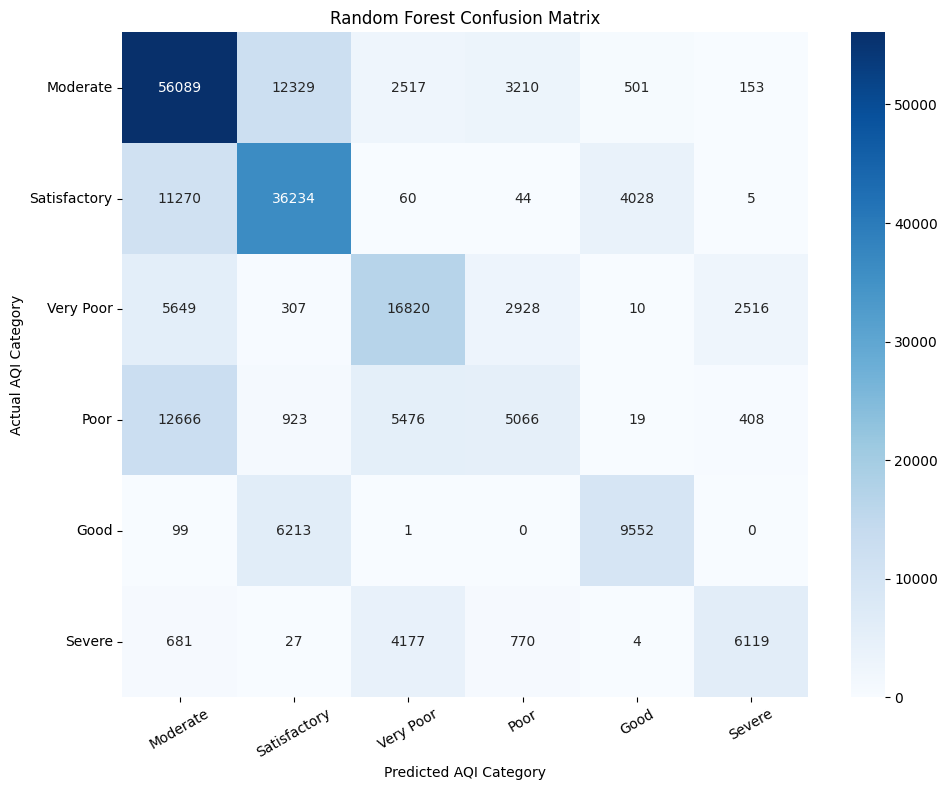

In [31]:
cm_data = confusion_matrix.collect()

cm = [[0 for _ in range(6)] for _ in range(6)]

for row in cm_data:
    cm[int(row["label"])][int(row["prediction"])] = row["count"]

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_names,
    yticklabels=label_names
)

plt.xlabel("Predicted AQI Category")
plt.ylabel("Actual AQI Category")
plt.title("Random Forest Confusion Matrix")
plt.xticks(rotation=30)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


# PART II — CLUSTERING

## 12. Station Data Preparation

For clustering, air-quality measurements are aggregated at the monitoring-station
level. Station metadata is joined with the pollutant measurements so that each
station can be analyzed according to its pollution profile.

In [32]:
stations_df = spark.read.csv(
    "stations.csv",
    header=True,
    inferSchema=True
)

print("Stations dataset:")
stations_df.printSchema()

print("Number of stations:", stations_df.count())

stations_df.show(5, truncate=False)

Stations dataset:
root
 |-- StationId: string (nullable = true)
 |-- StationName: string (nullable = true)
 |-- City: string (nullable = true)
 |-- State: string (nullable = true)
 |-- Status: string (nullable = true)

Number of stations: 230
+---------+----------------------------------------------+-----------------+--------------+------+
|StationId|StationName                                   |City             |State         |Status|
+---------+----------------------------------------------+-----------------+--------------+------+
|AP001    |Secretariat, Amaravati - APPCB                |Amaravati        |Andhra Pradesh|Active|
|AP002    |Anand Kala Kshetram, Rajamahendravaram - APPCB|Rajamahendravaram|Andhra Pradesh|NULL  |
|AP003    |Tirumala, Tirupati - APPCB                    |Tirupati         |Andhra Pradesh|NULL  |
|AP004    |PWD Grounds, Vijayawada - APPCB               |Vijayawada       |Andhra Pradesh|NULL  |
|AP005    |GVM Corporation, Visakhapatnam - APPCB        |Visakh

In [33]:
id="join_stations"
station_data = df_clean.join(
    stations_df.select("StationId", "StationName", "City", "State"),
    on="StationId",
    how="left"
)

print("Joined dataset:")
print("Rows:", station_data.count())
print("Columns:", len(station_data.columns))

station_data.select(
    "StationId",
    "StationName",
    "City",
    "State",
    "PM25",
    "PM10",
    "NO2",
    "SO2",
    "CO",
    "O3"
).show(5, truncate=False)

Joined dataset:
Rows: 2589083
Columns: 19
+---------+------------------------------+---------+--------------+-----+------+-----+-----+---+------+
|StationId|StationName                   |City     |State         |PM25 |PM10  |NO2  |SO2  |CO |O3    |
+---------+------------------------------+---------+--------------+-----+------+-----+-----+---+------+
|AP001    |Secretariat, Amaravati - APPCB|Amaravati|Andhra Pradesh|60.5 |98.0  |30.8 |11.85|0.1|126.4 |
|AP001    |Secretariat, Amaravati - APPCB|Amaravati|Andhra Pradesh|65.5 |111.25|24.2 |13.17|0.1|117.12|
|AP001    |Secretariat, Amaravati - APPCB|Amaravati|Andhra Pradesh|80.0 |132.0 |25.18|12.08|0.1|98.98 |
|AP001    |Secretariat, Amaravati - APPCB|Amaravati|Andhra Pradesh|81.5 |133.25|16.25|10.47|0.1|112.2 |
|AP001    |Secretariat, Amaravati - APPCB|Amaravati|Andhra Pradesh|75.25|116.0 |17.48|9.12 |0.1|106.35|
+---------+------------------------------+---------+--------------+-----+------+-----+-----+---+------+
only showing top 5 row

### 12.1 Station-Level Pollution Profiles

The joined air-quality data is aggregated for each monitoring station.
Average pollutant concentrations are calculated to create a pollution profile
for every station.

These station-level profiles are used as the input for K-Means clustering.

In [34]:
station_profiles = station_data.groupBy(
    "StationId", "StationName", "City", "State"
).agg(
    F.avg("PM25").alias("Avg_PM25"),
    F.avg("PM10").alias("Avg_PM10"),
    F.avg("NO2").alias("Avg_NO2"),
    F.avg("SO2").alias("Avg_SO2"),
    F.avg("CO").alias("Avg_CO"),
    F.avg("O3").alias("Avg_O3"),
    F.count("*").alias("Record_Count")
)

print("Station profiles created.")
print("Number of station profiles:", station_profiles.count())

station_profiles.show(10, truncate=False)

Station profiles created.
Number of station profiles: 110
+---------+------------------------------------------------+-----+-----+------------------+------------------+------------------+------------------+------------------+------------------+------------+
|StationId|StationName                                     |City |State|Avg_PM25          |Avg_PM10          |Avg_NO2           |Avg_SO2           |Avg_CO            |Avg_O3            |Record_Count|
+---------+------------------------------------------------+-----+-----+------------------+------------------+------------------+------------------+------------------+------------------+------------+
|DL016    |Jawaharlal Nehru Stadium, Delhi - DPCC          |Delhi|Delhi|97.52504448572549 |208.044480799373  |62.88886866893529 |17.75332307542012 |1.6295678824721447|39.59956224484779 |21136       |
|DL025    |North Campus, DU, Delhi - IMD                   |Delhi|Delhi|107.56441590213988|220.8945759197648 |25.738336303336585|NULL         

In [35]:
cluster_df = station_profiles.select(
    "StationId",
    "StationName",
    "City",
    "State",
    "Avg_PM25",
    "Avg_PM10",
    "Avg_NO2",
    "Avg_SO2",
    "Avg_CO",
    "Avg_O3"
).dropna()

print("Complete station profiles:", cluster_df.count())

cluster_df.show(10, truncate=False)

Complete station profiles: 80
+---------+------------------------------------------------+-----+-----+------------------+------------------+------------------+------------------+------------------+------------------+
|StationId|StationName                                     |City |State|Avg_PM25          |Avg_PM10          |Avg_NO2           |Avg_SO2           |Avg_CO            |Avg_O3            |
+---------+------------------------------------------------+-----+-----+------------------+------------------+------------------+------------------+------------------+------------------+
|DL016    |Jawaharlal Nehru Stadium, Delhi - DPCC          |Delhi|Delhi|97.52504448572549 |208.044480799373  |62.88886866893529 |17.75332307542012 |1.6295678824721447|39.59956224484779 |
|DL028    |Punjabi Bagh, Delhi - DPCC                      |Delhi|Delhi|120.64842639148733|124.61630439241654|71.09187024820268 |19.827875124626235|1.4112477405495996|228.15919973878763|
|DL037    |Vivek Vihar, Delhi - DPC

In [36]:
from pyspark.ml.feature import VectorAssembler

cluster_features = [
    "Avg_PM25",
    "Avg_PM10",
    "Avg_NO2",
    "Avg_SO2",
    "Avg_CO",
    "Avg_O3"
]

cluster_assembler = VectorAssembler(
    inputCols=cluster_features,
    outputCol="raw_features"
)

cluster_vector_df = cluster_assembler.transform(cluster_df)

cluster_vector_df.select(
    "StationId",
    "City",
    "raw_features"
).show(5, truncate=False)

+---------+-----+------------------------------------------------------------------------------------------------------------------+
|StationId|City |raw_features                                                                                                      |
+---------+-----+------------------------------------------------------------------------------------------------------------------+
|DL016    |Delhi|[97.52504448572549,208.044480799373,62.88886866893529,17.75332307542012,1.6295678824721447,39.59956224484779]     |
|DL028    |Delhi|[120.64842639148733,124.61630439241654,71.09187024820268,19.827875124626235,1.4112477405495996,228.15919973878763]|
|DL037    |Delhi|[106.6925572051546,229.96667832345034,33.24154349631216,18.017871656190632,1.456460218408742,39.46430843671211]   |
|DL020    |Delhi|[123.86490885416667,268.87202058504874,37.186590813821205,17.45560929237717,1.366255918416906,29.836606951553406] |
|DL018    |Delhi|[92.8969216024535,203.65985084054026,58.584557096602

In [37]:
from pyspark.ml.feature import StandardScaler

scaler = StandardScaler(
    inputCol="raw_features",
    outputCol="scaled_features",
    withMean=True,
    withStd=True
)

scaler_model = scaler.fit(cluster_vector_df)

cluster_scaled_df = scaler_model.transform(cluster_vector_df)

cluster_scaled_df.select(
    "StationId",
    "City",
    "scaled_features"
).show(5, truncate=False)

+---------+-----+----------------------------------------------------------------------------------------------------------------------+
|StationId|City |scaled_features                                                                                                       |
+---------+-----+----------------------------------------------------------------------------------------------------------------------+
|DL016    |Delhi|[0.8695005188937994,0.9985856707542476,1.6967359775938575,0.7860834055729353,0.17307490900723294,0.12893554277640218] |
|DL028    |Delhi|[1.530201057842641,-0.19798458877653563,2.1569558050609516,1.08305647928147,0.08187270086720745,7.536248042411126]    |
|DL037    |Delhi|[1.1314423325624092,1.313005219527737,0.03340740890375778,0.8239536557827163,0.10075999994975716,0.12362227829975184] |
|DL020    |Delhi|[1.6221050753982305,1.8710058554281648,0.25473968322665086,0.7434655415046442,0.0630775796722025,-0.2545890637540844] |
|DL018    |Delhi|[0.7372619347731381,0.93

## 13. K Selection and Clustering Evaluation

The optimal number of clusters is selected by comparing clustering quality
using the Silhouette Score. The Elbow Method is also used as a supporting
evaluation technique.

In [38]:
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator

silhouette_scores = []

evaluator = ClusteringEvaluator(
    featuresCol="scaled_features",
    metricName="silhouette",
    distanceMeasure="squaredEuclidean"
)

for k in range(2, 9):
    kmeans = KMeans(
        k=k,
        seed=42,
        featuresCol="scaled_features",
        predictionCol="prediction"
    )

    model = kmeans.fit(cluster_scaled_df)
    predictions_k = model.transform(cluster_scaled_df)

    score = evaluator.evaluate(predictions_k)
    silhouette_scores.append((k, score))

    print(f"K = {k}  |  Silhouette Score = {score:.4f}")

K = 2  |  Silhouette Score = 0.5871
K = 3  |  Silhouette Score = 0.6585
K = 4  |  Silhouette Score = 0.2987
K = 5  |  Silhouette Score = 0.3391
K = 6  |  Silhouette Score = 0.4336
K = 7  |  Silhouette Score = 0.3363
K = 8  |  Silhouette Score = 0.3741


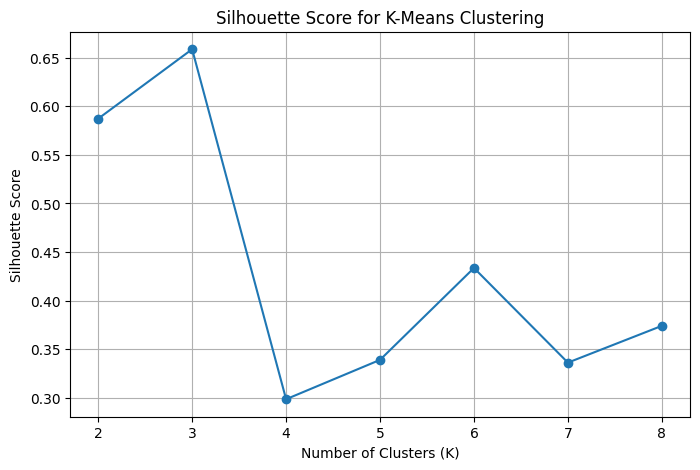

In [39]:
import matplotlib.pyplot as plt

k_values = [x[0] for x in silhouette_scores]
silhouette_values = [x[1] for x in silhouette_scores]

plt.figure(figsize=(8, 5))
plt.plot(k_values, silhouette_values, marker="o")

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score for K-Means Clustering")
plt.xticks(k_values)
plt.grid(True)
plt.show()

## 14. K-Means Clustering

K-Means clustering is applied to group monitoring stations with similar
pollution characteristics. Based on the clustering evaluation, three clusters
(K=3) are selected for the final model.

In [40]:
from pyspark.ml.clustering import KMeans

kmeans_final = KMeans(
    k=3,
    seed=42,
    featuresCol="scaled_features",
    predictionCol="cluster"
)

kmeans_model = kmeans_final.fit(cluster_scaled_df)

clustered_df = kmeans_model.transform(cluster_scaled_df)

print("Final K-Means model trained!")
print("Number of clusters:", kmeans_model.getK())

clustered_df.select(
    "StationId",
    "City",
    "cluster"
).show(20, truncate=False)

Final K-Means model trained!
Number of clusters: 3
+---------+-------------+-------+
|StationId|City         |cluster|
+---------+-------------+-------+
|DL016    |Delhi        |0      |
|DL028    |Delhi        |0      |
|DL037    |Delhi        |0      |
|DL020    |Delhi        |0      |
|DL018    |Delhi        |0      |
|DL010    |Delhi        |0      |
|DL036    |Delhi        |1      |
|DL009    |Delhi        |0      |
|DL027    |Delhi        |1      |
|DL005    |Delhi        |0      |
|DL024    |Delhi        |0      |
|AP005    |Visakhapatnam|1      |
|DL022    |Delhi        |1      |
|DL038    |Delhi        |0      |
|DL008    |Delhi        |0      |
|BR006    |Patna        |1      |
|DL026    |Delhi        |0      |
|HR012    |Gurugram     |1      |
|AP001    |Amaravati    |1      |
|GJ001    |Ahmedabad    |2      |
+---------+-------------+-------+
only showing top 20 rows


In [41]:
cluster_profile = clustered_df.groupBy("cluster").agg(
    F.count("*").alias("Station_Count"),
    F.round(F.avg("Avg_PM25"), 2).alias("Avg_PM25"),
    F.round(F.avg("Avg_PM10"), 2).alias("Avg_PM10"),
    F.round(F.avg("Avg_NO2"), 2).alias("Avg_NO2"),
    F.round(F.avg("Avg_SO2"), 2).alias("Avg_SO2"),
    F.round(F.avg("Avg_CO"), 2).alias("Avg_CO"),
    F.round(F.avg("Avg_O3"), 2).alias("Avg_O3")
).orderBy("cluster")

cluster_profile.show(truncate=False)

+-------+-------------+--------+--------+-------+-------+------+------+
|cluster|Station_Count|Avg_PM25|Avg_PM10|Avg_NO2|Avg_SO2|Avg_CO|Avg_O3|
+-------+-------------+--------+--------+-------+-------+------+------+
|0      |25           |113.13  |225.93  |49.52  |15.12  |1.4   |44.08 |
|1      |54           |45.78   |98.4    |24.34  |10.19  |0.74  |32.67 |
|2      |1            |67.27   |111.49  |59.47  |52.8   |22.0  |39.07 |
+-------+-------------+--------+--------+-------+-------+------+------+



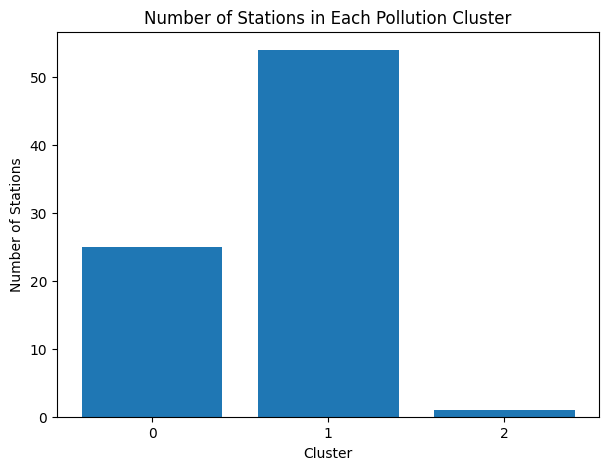

In [42]:
cluster_counts = (
    clustered_df.groupBy("cluster")
    .count()
    .orderBy("cluster")
    .toPandas()
)

plt.figure(figsize=(7, 5))

plt.bar(
    cluster_counts["cluster"].astype(str),
    cluster_counts["count"]
)

plt.xlabel("Cluster")
plt.ylabel("Number of Stations")
plt.title("Number of Stations in Each Pollution Cluster")

plt.show()

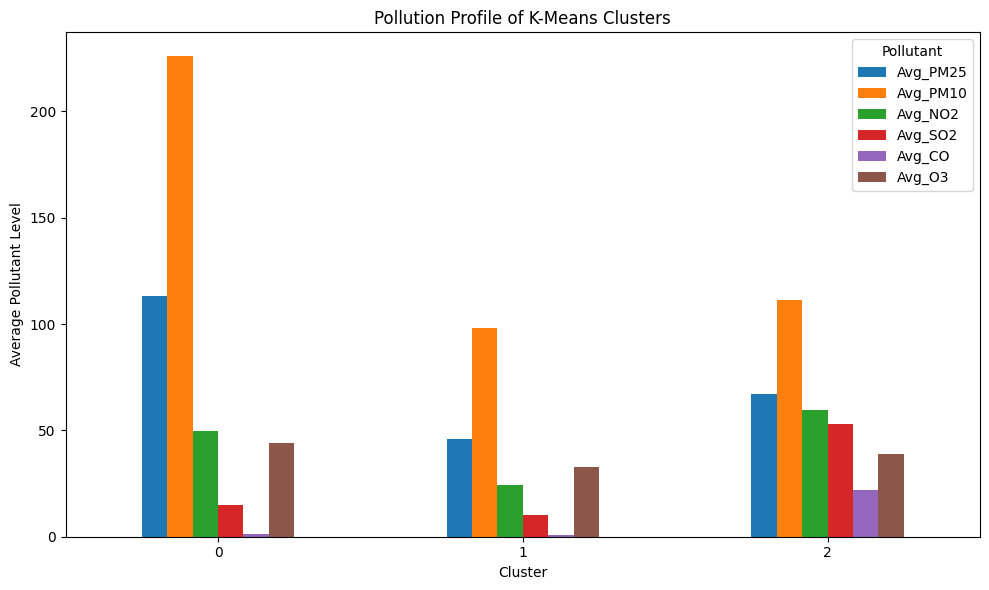

In [43]:
profile_pd = cluster_profile.toPandas()

pollutants = [
    "Avg_PM25",
    "Avg_PM10",
    "Avg_NO2",
    "Avg_SO2",
    "Avg_CO",
    "Avg_O3"
]

profile_pd.set_index("cluster")[pollutants].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.xlabel("Cluster")
plt.ylabel("Average Pollutant Level")
plt.title("Pollution Profile of K-Means Clusters")
plt.xticks(rotation=0)
plt.legend(title="Pollutant")
plt.tight_layout()
plt.show()

## 16. PCA Visualization

Principal Component Analysis (PCA) is used to reduce the pollution feature
space to two dimensions so that the separation of the identified station
clusters can be visualized.

In [44]:
from pyspark.ml.feature import PCA

pca = PCA(
    k=2,
    inputCol="scaled_features",
    outputCol="pca_features"
)

pca_model = pca.fit(clustered_df)

pca_result = pca_model.transform(clustered_df)

print("PCA completed.")

pca_result.select(
    "StationId",
    "City",
    "cluster",
    "pca_features"
).show(5, truncate=False)

PCA completed.
+---------+-----+-------+-----------------------------------------+
|StationId|City |cluster|pca_features                             |
+---------+-----+-------+-----------------------------------------+
|DL016    |Delhi|0      |[-2.129099598346052,-0.27562796713869386]|
|DL028    |Delhi|0      |[-3.49318887320646,-0.5332877823955267]  |
|DL037    |Delhi|0      |[-1.6255579789384575,-0.2500646424845293]|
|DL020    |Delhi|0      |[-2.1598236429050055,-0.6549155474364271]|
|DL018    |Delhi|0      |[-1.6823217251746598,-0.4383914094049016]|
+---------+-----+-------+-----------------------------------------+
only showing top 5 rows


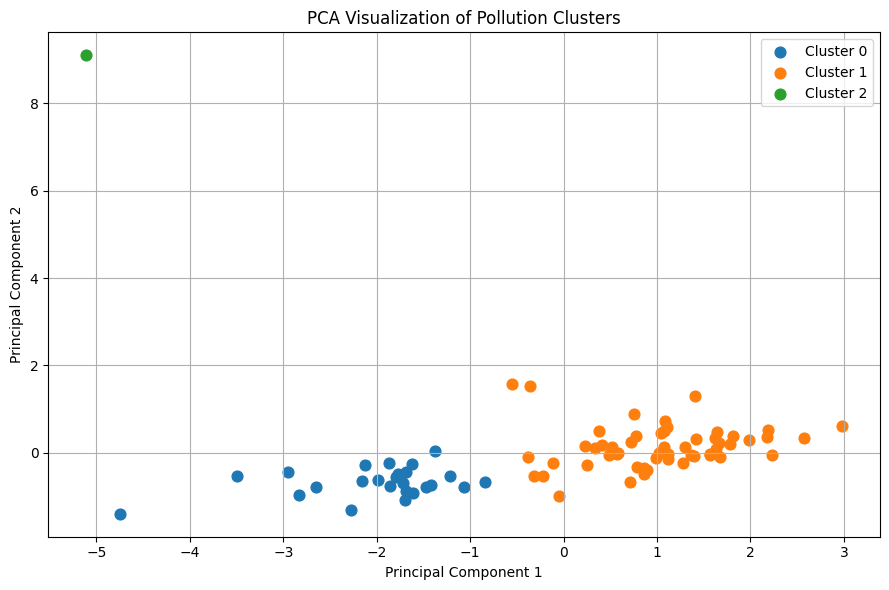

In [45]:
pca_pd = pca_result.select(
    "cluster",
    "pca_features"
).toPandas()

pca_pd["PC1"] = pca_pd["pca_features"].apply(lambda x: float(x[0]))
pca_pd["PC2"] = pca_pd["pca_features"].apply(lambda x: float(x[1]))

plt.figure(figsize=(9, 6))

for cluster_id in sorted(pca_pd["cluster"].unique()):
    cluster_data = pca_pd[pca_pd["cluster"] == cluster_id]

    plt.scatter(
        cluster_data["PC1"],
        cluster_data["PC2"],
        label=f"Cluster {cluster_id}",
        s=60
    )

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Visualization of Pollution Clusters")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## 17. Clustering Inference

K-Means clustering identified three distinct pollution profiles among the
80 complete station profiles.

- **Cluster 0:** Stations with high particulate pollution.
- **Cluster 1:** Stations with comparatively lower pollutant concentrations.
- **Cluster 2:** A single station with an unusual SO2 and CO profile.

The Silhouette Score of **0.6585** indicates reasonably well-separated
clusters.

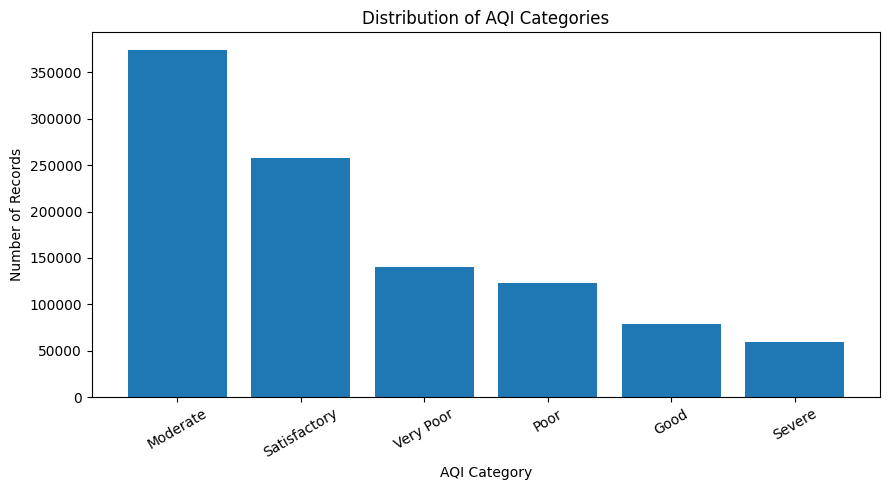

In [46]:
aqi_counts = (
    classification_df
    .groupBy("AQI_Bucket")
    .count()
    .orderBy(F.desc("count"))
    .toPandas()
)

plt.figure(figsize=(9, 5))

plt.bar(
    aqi_counts["AQI_Bucket"],
    aqi_counts["count"]
)

plt.xlabel("AQI Category")
plt.ylabel("Number of Records")
plt.title("Distribution of AQI Categories")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

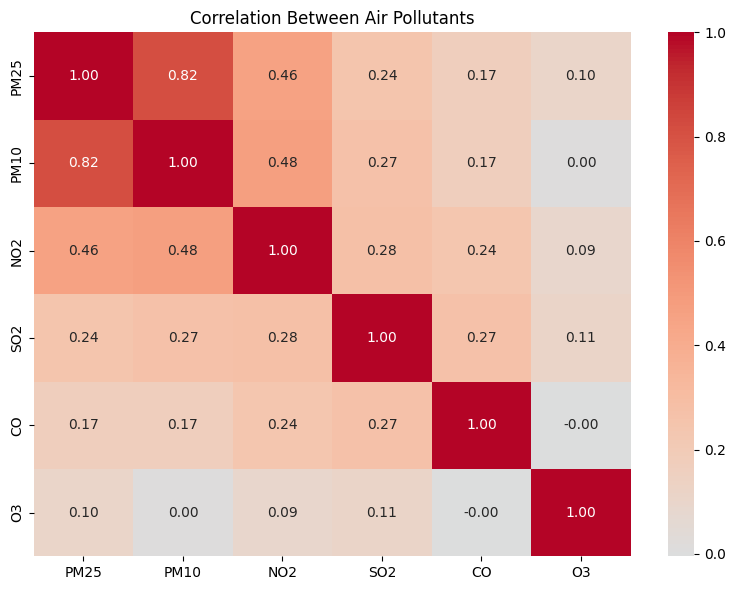

In [47]:
correlation_df = (
    df_clean
    .select("PM25", "PM10", "NO2", "SO2", "CO", "O3")
    .dropna()
    .sample(False, 0.02, seed=42)
    .toPandas()
)

correlation_matrix = correlation_df.corr()

plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Between Air Pollutants")
plt.tight_layout()
plt.show()

In [48]:
city_pollution = (
    station_profiles
    .groupBy("City")
    .agg(
        F.round(F.avg("Avg_PM25"), 2).alias("PM25"),
        F.round(F.avg("Avg_PM10"), 2).alias("PM10")
    )
    .orderBy(F.desc("PM25"))
)

city_pd = city_pollution.toPandas()

print("Top 10 cities by average PM2.5:")
city_pd.head(10)

Top 10 cities by average PM2.5:


,City,PM25,PM10
0,Delhi,109.40,215.83
1,Lucknow,105.56,NaN
2,Gurugram,81.75,140.96
3,Patna,67.35,122.02
4,Ahmedabad,67.27,111.49
5,Brajrajnagar,66.45,125.42
6,Jorapokhar,63.97,149.72
7,Talcher,63.91,171.77
8,Guwahati,61.78,113.88
9,Kolkata,56.05,105.77


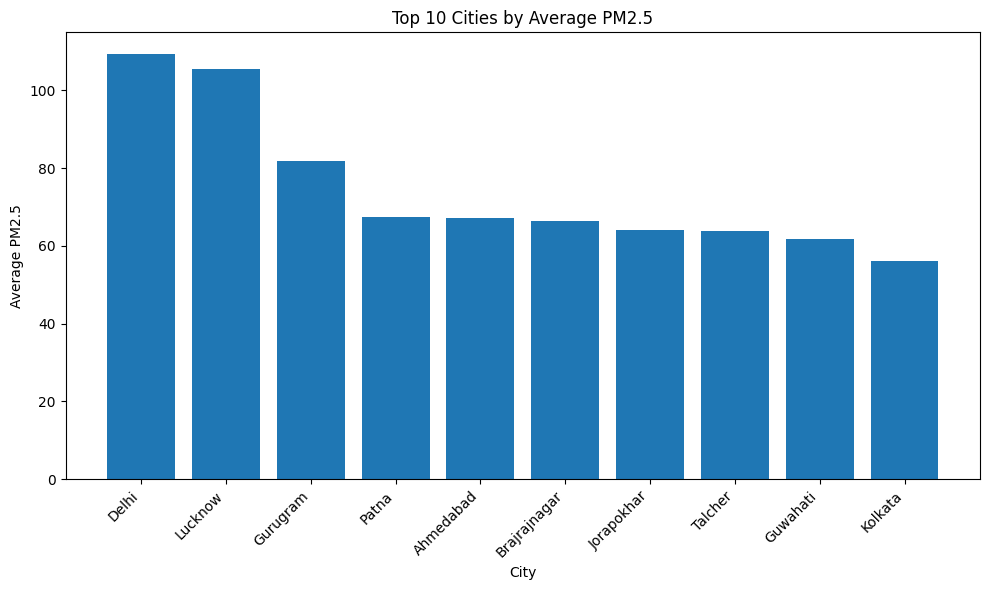

In [49]:
top_cities = city_pd.head(10)

plt.figure(figsize=(10, 6))

plt.bar(
    top_cities["City"],
    top_cities["PM25"]
)

plt.xlabel("City")
plt.ylabel("Average PM2.5")
plt.title("Top 10 Cities by Average PM2.5")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 15. Cluster Evaluation

The quality of the K-Means clustering is evaluated using Silhouette Score,
Davies-Bouldin Index, and Calinski-Harabasz Index.

The selected K=3 solution achieved a Silhouette Score of 0.6585, indicating
well-separated and reasonably cohesive station clusters.

In [51]:
from pyspark.ml.evaluation import ClusteringEvaluator
from sklearn.metrics import davies_bouldin_score, calinski_harabasz_score

# Silhouette
evaluator = ClusteringEvaluator(
    featuresCol="scaled_features",
    predictionCol="cluster",
    metricName="silhouette",
    distanceMeasure="squaredEuclidean"
)

silhouette_final = evaluator.evaluate(clustered_df)

# Convert scaled features to Pandas
cluster_features_pd = cluster_scaled_df.select(
    "scaled_features"
).toPandas()

X_scaled = cluster_features_pd["scaled_features"].apply(
    lambda x: list(x)
).tolist()

# Cluster labels
cluster_labels = clustered_df.select(
    "cluster"
).toPandas()["cluster"].values

# Davies-Bouldin Index
db_score = davies_bouldin_score(
    X_scaled,
    cluster_labels
)

# Calinski-Harabasz Score
ch_score = calinski_harabasz_score(
    X_scaled,
    cluster_labels
)

print(f"Silhouette Score:        {silhouette_final:.4f}")
print(f"Davies-Bouldin Index:    {db_score:.4f}")
print(f"Calinski-Harabasz Score: {ch_score:.4f}")

Silhouette Score:        0.6585
Davies-Bouldin Index:    0.6008
Calinski-Harabasz Score: 55.9135


In [52]:
df_clean.write \
    .mode("overwrite") \
    .parquet("air_quality_parquet")

print("Dataset successfully written in Parquet format.")

Dataset successfully written in Parquet format.


In [53]:
parquet_df = spark.read.parquet("air_quality_parquet")

print("Parquet dataset loaded successfully!")
print("Rows:", parquet_df.count())
print("Columns:", len(parquet_df.columns))

parquet_df.show(5)


Parquet dataset loaded successfully!
Rows: 2589083
Columns: 16
+---------+-------------------+-----+-----+----+----+----+----+----+-----+-----+-------+-------+------+-----+----------+
|StationId|           Datetime| PM25| PM10|  NO| NO2| NOx| NH3|  CO|  SO2|   O3|Benzene|Toluene|Xylene|  AQI|AQI_Bucket|
+---------+-------------------+-----+-----+----+----+----+----+----+-----+-----+-------+-------+------+-----+----------+
|    HR013|2020-04-24 20:00:00| 31.7|55.95|3.73| 3.0|2.99|NULL|0.49|12.08|94.94|  10.22|   2.41|  1.26|129.0|  Moderate|
|    HR013|2020-04-24 21:00:00| 39.8|52.57| 3.7|3.03|2.98|NULL|0.54|12.62|78.75|  11.04|   2.28|  1.25|129.0|  Moderate|
|    HR013|2020-04-24 22:00:00|46.51|60.72|3.71| 3.0|2.97|NULL|0.56|13.12|64.16|  11.75|   2.21|  1.25|119.0|  Moderate|
|    HR013|2020-04-24 23:00:00|50.36|70.97|3.71|2.98|2.96|NULL|0.61|13.75|63.51|   12.3|    2.1|  1.22|116.0|  Moderate|
|    HR013|2020-04-25 00:00:00|57.33|79.47|3.71|2.97|2.96|NULL|0.64|15.96|72.22|  12.84|  

In [54]:
from pyspark.sql import functions as F

parquet_aqi_summary = (
    parquet_df
    .groupBy("AQI_Bucket")
    .agg(
        F.count("*").alias("Record_Count"),
        F.round(F.avg("AQI"), 2).alias("Average_AQI")
    )
    .orderBy(F.desc("Record_Count"))
)

parquet_aqi_summary.show(truncate=False)

+------------+------------+-----------+
|AQI_Bucket  |Record_Count|Average_AQI|
+------------+------------+-----------+
|Moderate    |675008      |138.18     |
|NULL        |570190      |NULL       |
|Satisfactory|530164      |76.09      |
|Very Poor   |301150      |338.43     |
|Poor        |239990      |246.14     |
|Good        |152113      |39.09      |
|Severe      |120468      |524.61     |
+------------+------------+-----------+



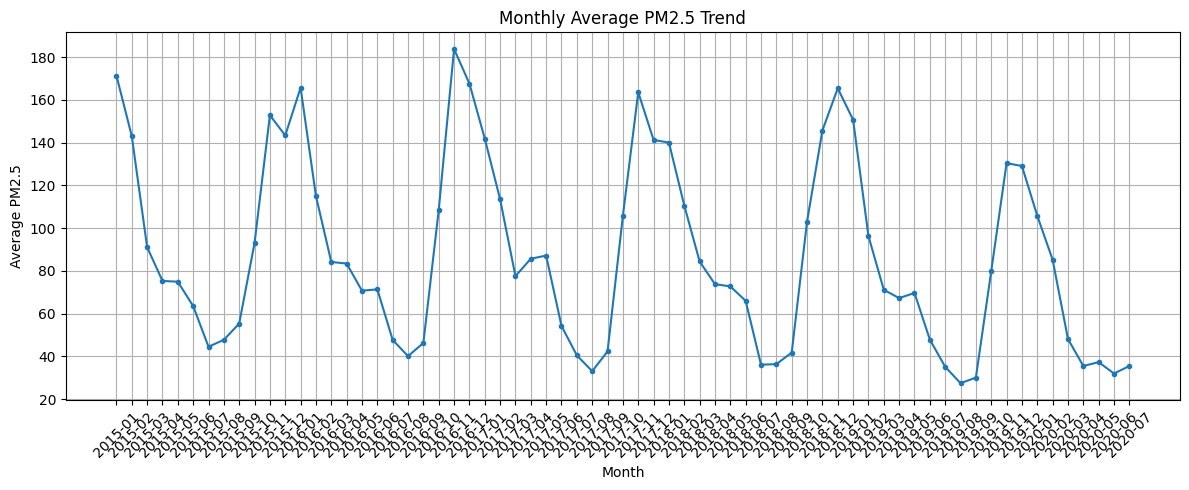

In [55]:
monthly_pm25 = (
    df_clean
    .withColumn("YearMonth", F.date_format("Datetime", "yyyy-MM"))
    .groupBy("YearMonth")
    .agg(
        F.round(F.avg("PM25"), 2).alias("Avg_PM25")
    )
    .orderBy("YearMonth")
)

monthly_pd = monthly_pm25.toPandas()

plt.figure(figsize=(12, 5))

plt.plot(
    monthly_pd["YearMonth"],
    monthly_pd["Avg_PM25"],
    marker="o",
    markersize=3
)

plt.xlabel("Month")
plt.ylabel("Average PM2.5")
plt.title("Monthly Average PM2.5 Trend")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

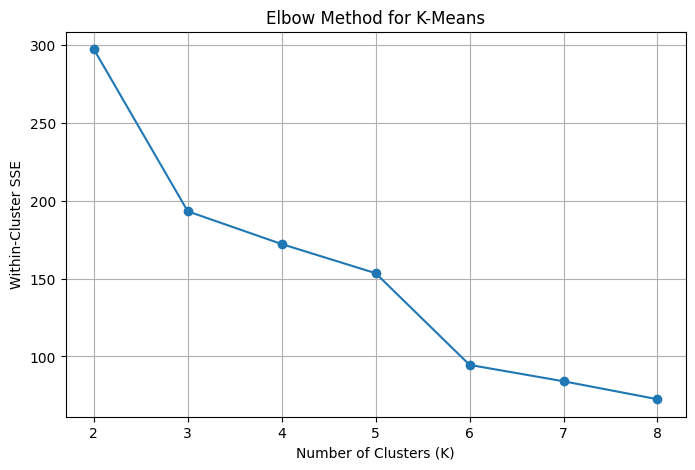

In [56]:
# Elbow Method for K-Means

elbow_scores = []

for k in range(2, 9):
    kmeans = KMeans(
        k=k,
        seed=42,
        featuresCol="scaled_features",
        predictionCol="prediction"
    )

    model = kmeans.fit(cluster_scaled_df)
    elbow_scores.append((k, model.summary.trainingCost))

elbow_pd = pd.DataFrame(elbow_scores, columns=["K", "SSE"])

plt.figure(figsize=(8,5))
plt.plot(elbow_pd["K"], elbow_pd["SSE"], marker="o")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Within-Cluster SSE")
plt.title("Elbow Method for K-Means")
plt.grid(True)
plt.show()

# 18. Conclusion and Future Scope

## Conclusion

This project demonstrated the use of PySpark and Big Data processing
techniques to analyze large-scale air-quality data from monitoring stations
across India.

The classification analysis showed that Random Forest performed better than
Logistic Regression, achieving an accuracy of **62.78%**. PM10 and PM2.5 were
the most influential features, with a combined feature importance of
approximately **77.11%**.

The clustering analysis identified **three pollution profiles** among the
monitoring stations. The selected K=3 solution achieved a Silhouette Score of
**0.6585**, showing meaningful separation between the station groups.

The exploratory analysis also revealed temporal and city-wise variations in
pollution levels and demonstrated the use of Spark and Parquet for processing
the large dataset.

## Future Scope

- Real-time air-quality monitoring using IoT data streams.
- Machine-learning-based AQI forecasting.
- Interactive pollution dashboards.
- Automated alerts for high-pollution episodes.
- Cloud-based deployment for large-scale data processing.
- Spatial hotspot detection using geographic information.